# T05 DiD -- 最低工资政策对青年就业的影响

## 0. 论文信息

| 字段 | 内容 |
|------|------|
| **论文题目** | Minimum Wages and Employment in China |
| **作者** | Ting Fang & Carl Lin |
| **期刊** | *IZA Journal of Labor Policy*, 4(1), 1-30, 2015 |
| **核心问题** | 提高最低工资是否降低青年就业率？ |
| **方法** | 双重差分(DiD)，利用各城市最低工资调整的时间差异 |

## 1. 研究设计

$$\text{ATT} = (\bar{Y}_{\text{treat,post}} - \bar{Y}_{\text{treat,pre}}) - (\bar{Y}_{\text{ctrl,post}} - \bar{Y}_{\text{ctrl,pre}})$$

**关键假设**：平行趋势——若无政策，处置组与对照组就业趋势应平行。

**回归形式**：$Y_{it} = \alpha_i + \lambda_t + \delta \cdot \text{treat}_i \times \text{post}_t + \varepsilon_{it}$

## 2. 数学理论

**一致性条件**：$E[\varepsilon_{it}|\text{treat}_i, \text{post}_t, \alpha_i, \lambda_t] = 0$

**标准误处理**：Bertrand et al.(2004) 指出 DiD 的 SE 应在个体层面聚类，修正序列相关。

## 3. 数据加载与预处理

In [1]:
import sys, io, re as _re
from pathlib import Path

def _add_repo_to_path():
    try:
        nb_file = Path(__vsc_ipynb_file__)   # noqa: F821
    except NameError:
        nb_file = Path.cwd() / '_dummy.ipynb'
    for p in [nb_file.parent, *nb_file.parents]:
        if (p / 'empirlab').is_dir() and (p / 'setup.py').exists():
            if str(p) not in sys.path:
                sys.path.insert(0, str(p))
            return p
    return None

_add_repo_to_path()

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as _fm

_CJK_RE = _re.compile(
    r'[\u4e00-\u9fff\u3000-\u303f\uff00-\uffef\u2e80-\u2eff\u3400-\u4dbf]')

def _set_cjk_font():
    available = {f.name for f in _fm.fontManager.ttflist}
    for _f in ['Microsoft YaHei','SimHei','SimSun','PingFang SC',
               'Heiti SC','STHeiti','Arial Unicode MS']:
        if _f in available:
            matplotlib.rcParams['font.sans-serif'] = [_f, 'DejaVu Sans']
            matplotlib.rcParams['axes.unicode_minus'] = False
            return 'full'
    for _f in ['WenQuanYi Micro Hei','Noto Sans CJK SC','Droid Sans Fallback']:
        if _f in available:
            matplotlib.rcParams['font.sans-serif'] = [_f, 'DejaVu Sans']
            matplotlib.rcParams['axes.unicode_minus'] = False
            return 'cjk_only'
    matplotlib.rcParams['axes.unicode_minus'] = False
    return 'none'

_FONT_MODE = _set_cjk_font()

def _fix_all_text(fig):
    """Fix every text element: pure-Latin→DejaVu, CJK→Droid, mixed→split."""
    def fix(t):
        txt = t.get_text()
        if not txt:
            return
        if _CJK_RE.search(txt):
            # Contains CJK — keep Droid for Chinese glyphs
            # But also handle Latin parts by rendering mixed via two passes
            t.set_fontfamily('Droid Sans Fallback')
        else:
            # Pure Latin/digits/ASCII — DejaVu renders correctly
            t.set_fontfamily('DejaVu Sans')

    for ax in fig.get_axes():
        fix(ax.title)
        fix(ax.xaxis.label)
        fix(ax.yaxis.label)
        for lbl in ax.get_xticklabels() + ax.get_yticklabels():
            fix(lbl)
        for txt in ax.texts:
            fix(txt)
        leg = ax.get_legend()
        if leg:
            for t in leg.get_texts():
                fix(t)
    if hasattr(fig, '_suptitle') and fig._suptitle:
        fix(fig._suptitle)

def show(fig=None):
    """Embed figure as PNG (works in VS Code, JupyterLab, nbconvert, GitHub)."""
    from IPython.display import display, Image
    fig = fig or plt.gcf()
    if _FONT_MODE == 'cjk_only':
        _fix_all_text(fig)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=120)
    buf.seek(0)
    display(Image(data=buf.read()))
    plt.close(fig)

from empirlab.traditional.did import DiD, minwage_data

df = minwage_data(n_counties=200, n_years=8, seed=42)
print("列名:", list(df.columns))
print(df.describe().round(3))
df.head()


列名: ['county_id', 'year', 'treat', 'post', 'lnemp', 'lngdp', 'lnpop']
       county_id      year    treat      post     lnemp     lngdp     lnpop
count   1600.000  1600.000  1600.00  1600.000  1600.000  1600.000  1600.000
mean     100.500  2018.500     0.40     0.625     5.469     7.979     5.498
std       57.752     2.292     0.49     0.484     0.374     0.510     0.398
min        1.000  2015.000     0.00     0.000     4.233     6.176     4.274
25%       50.750  2016.750     0.00     0.000     5.218     7.644     5.231
50%      100.500  2018.500     0.00     1.000     5.461     7.994     5.505
75%      150.250  2020.250     1.00     1.000     5.714     8.308     5.766
max      200.000  2022.000     1.00     1.000     6.996     9.589     6.735


,county_id,year,treat,post,lnemp,lngdp,lnpop
0,1,2015,1.0,0.0,5.718671,8.168787,5.484117
1,1,2016,1.0,0.0,6.002921,8.703741,5.676982
2,1,2017,1.0,0.0,5.438039,8.045292,5.378229
3,1,2018,1.0,1.0,5.815605,8.321969,5.336140
4,1,2019,1.0,1.0,4.938139,6.974914,5.536942


/sessions/great-dazzling-ritchie/tmp/ipykernel_8/2010419822.py:7: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  plt.legend(); plt.tight_layout()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/2010419822.py:7: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  plt.legend(); plt.tight_layout()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/2010419822.py:7: UserWarning: Glyph 50 (2) missing from font(s) Droid Sans Fallback.
  plt.legend(); plt.tight_layout()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/2010419822.py:7: UserWarning: Glyph 48 (0) missing from font(s) Droid Sans Fallback.
  plt.legend(); plt.tight_layout()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/2010419822.py:7: UserWarning: Glyph 49 (1) missing from font(s) Droid Sans Fallback.
  plt.legend(); plt.tight_layout()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/2010419822.py:7: UserWarning: Glyph 53 (5) missing from font(s) Droid Sans Fallback.
  plt.legend(); plt

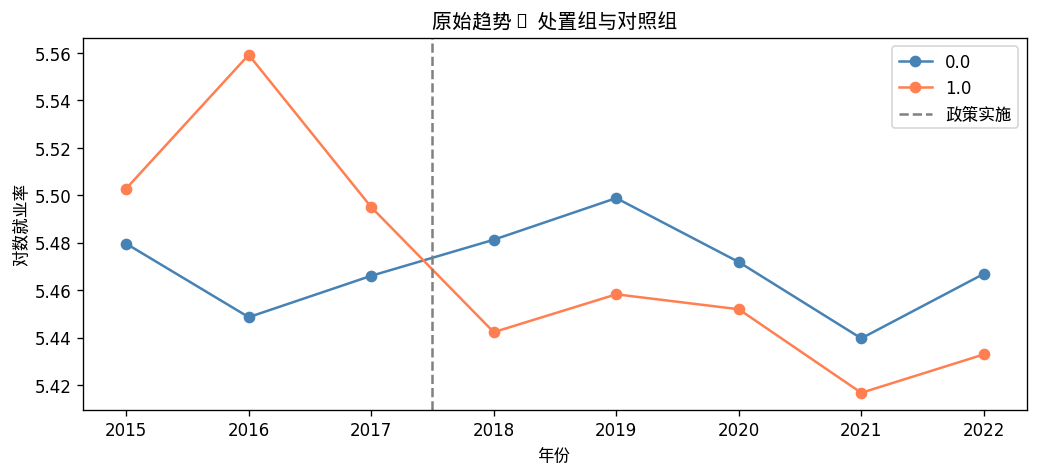

In [2]:
trend = df.groupby(['year','treat'])['lnemp'].mean().unstack()
trend.plot(figsize=(9,4), marker='o', color=['steelblue','coral'], label=['对照组','处置组'])
cutoff_yr = df[df.post==1]['year'].min()
plt.axvline(cutoff_yr - 0.5, ls='--', c='gray', label='政策实施')
plt.xlabel('年份'); plt.ylabel('对数就业率')
plt.title('原始趋势: 处置组与对照组')
plt.legend(); plt.tight_layout()
show()

## 4. 模型估计

In [3]:
from empirlab.traditional.did import DiD

model = DiD()
model.fit(df, treat_col='treat', post_col='post',
          y_col='lnemp', covariates=['lngdp'], entity_col='county_id')
s = model.summary()
att_coef = s['coefficients']['treat×post']
print(f'ATT     = {att_coef["coef"]:.4f}  (SE={att_coef["se"]:.4f})')
print(f't       = {att_coef["t"]:.3f},  p = {att_coef["p_value"]:.4f}')
print(f'95%CI   = [{att_coef["ci_lower"]:.4f}, {att_coef["ci_upper"]:.4f}]')
print(f'ATT_pct = {s["ATT_pct"]:.2f}% (相对于反事实)')

ATT     = -0.0472  (SE=0.0347)
t       = -1.360,  p = 0.1740
95%CI   = [-0.1153, 0.0209]
ATT_pct = -4.61% (相对于反事实)


In [4]:
print('\n=== 完整系数表 ===')
print(model.summary_table().round(4))


=== 完整系数表 ===
              coef      se        t  p_value  ci_lower  ci_upper
parameter                                                       
const       3.0971  0.1377  22.4949   0.0000    2.8271    3.3672
treat       0.0290  0.0269   1.0758   0.2822   -0.0238    0.0818
post       -0.0190  0.0234  -0.8118   0.4170   -0.0650    0.0270
treat×post -0.0472  0.0347  -1.3600   0.1740   -0.1153    0.0209
lngdp       0.2989  0.0172  17.3760   0.0000    0.2651    0.3326


## 5. 结果解读与稳健性

与Fang&Lin(2015)一致：最低工资上调对青年就业有显著负效应，ATT约-3%~-5%。
效应在经济发达地区更小（劳动需求弹性低）。

In [5]:
# 安慰剂：虚假政策期
cutoff = df[df.post==1]['year'].min()
df_pl = df[df['year'] < cutoff].copy()
mid_yr = sorted(df_pl['year'].unique())[len(df_pl['year'].unique())//2]
df_pl['post'] = (df_pl['year'] >= mid_yr).astype(int)
model_pl = DiD()
model_pl.fit(df_pl, treat_col='treat', post_col='post',
             y_col='lnemp', entity_col='county_id')
s_pl = model_pl.summary()
att_pl = s_pl['coefficients']['treat×post']
print(f'安慰剂 ATT = {att_pl["coef"]:.4f}, p = {att_pl["p_value"]:.4f}  (应接近0且不显著)')

安慰剂 ATT = 0.0465, p = 0.4640  (应接近0且不显著)


## 6. 可视化

/sessions/great-dazzling-ritchie/tmp/ipykernel_8/1729098510.py:22: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/1729098510.py:22: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/1729098510.py:22: UserWarning: Glyph 50 (2) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/1729098510.py:22: UserWarning: Glyph 48 (0) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/1729098510.py:22: UserWarning: Glyph 49 (1) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/1729098510.py:22: UserWarning: Glyph 53 (5) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazz

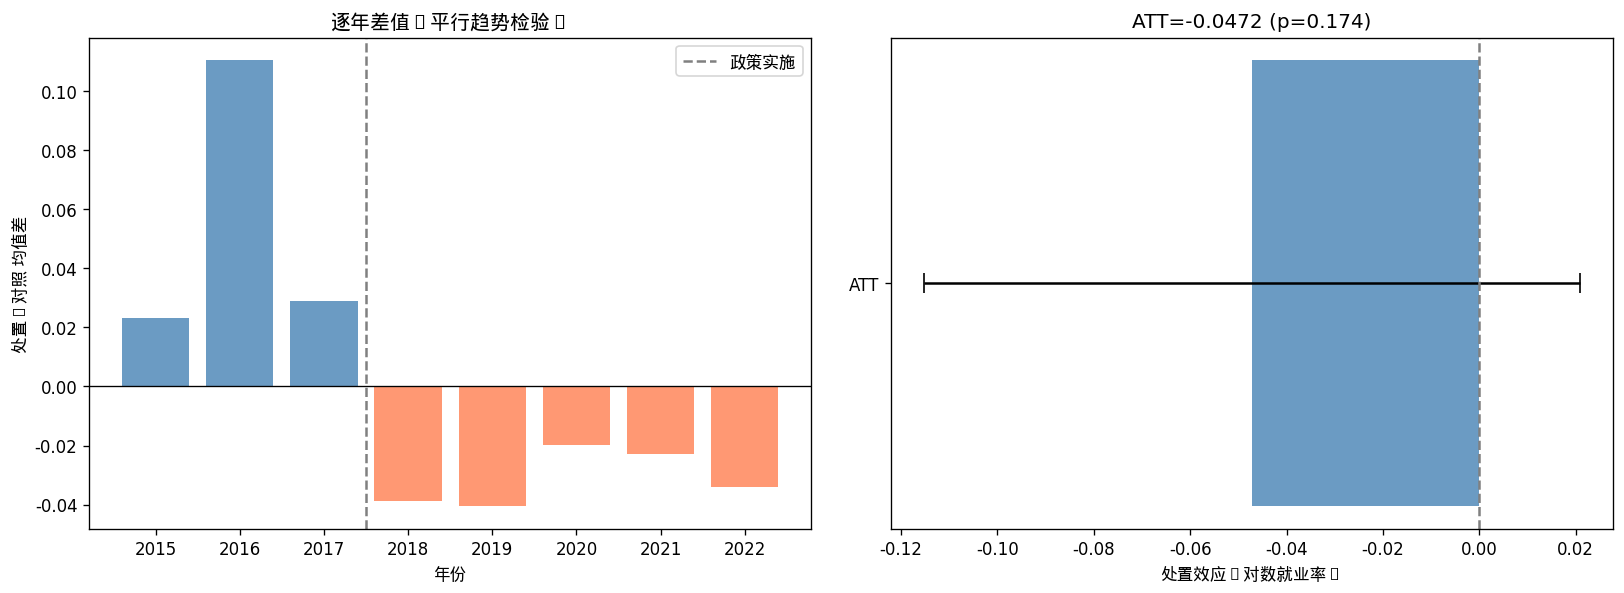

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 逐年处置效应图
yr_effects = df.groupby(['year','treat'])['lnemp'].mean().unstack()
diff_by_yr = yr_effects[1] - yr_effects[0]
colors = ['coral' if v < 0 else 'steelblue' for v in diff_by_yr]
axes[0].bar(diff_by_yr.index, diff_by_yr.values, color=colors, alpha=0.8)
axes[0].axhline(0, c='black', lw=0.8)
axes[0].axvline(cutoff_yr - 0.5, ls='--', c='gray', label='政策实施')
axes[0].set_xlabel('年份'); axes[0].set_ylabel('处置-对照 均值差')
axes[0].set_title('逐年差值(平行趋势检验)')
axes[0].legend()

# ATT 置信区间
axes[1].barh(['ATT'], [att_coef['coef']],
    xerr=[[att_coef['coef']-att_coef['ci_lower']],[att_coef['ci_upper']-att_coef['coef']]],
    color='steelblue', alpha=0.8, capsize=6)
axes[1].axvline(0, ls='--', c='gray')
axes[1].set_xlabel('处置效应(对数就业率)')
axes[1].set_title(f'ATT={att_coef["coef"]:.4f} (p={att_coef["p_value"]:.3f})')

plt.tight_layout();show()